## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 4 (Section 001 - Spring 2022)

The goal of this quiz is to give you the opportunity to test out some of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your new programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

---
# Academic integrity statement [10 points]

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.


<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---

# Finding Planets

You are working for NASA looking for planets outside of our solar system. One way of finding these planets is to measure how fast stars are moving towards you and modeling the motion using a *sinusoid,* which looks like the following:

$$ v(t) = A*\sin\left(\frac{2\pi t}{P} + C \right) + S$$


Where $v$ is the velocity (speed), $t$ is the time, $A$ is the called amplitude, $P$ is called the period, $C$ is called the phase, and $S$ is called the peculiar velocity. Stars moving fast enough (I.e., with a large enough amplitude) likely have a planet around them.

You’ve been given a dataset and you are tasked with finding the best fit amplitude.

#### &#9989;&nbsp; **Part 1 (15 points):**
Read in the csv file provided and describe the dataset.

In [ ]:
#Write your code for reading in the dataset here

In [1]:
### ANSWER ###
import pandas as pd 

df = pd.read_csv("velocity_data.csv")
df.describe()

,Time (Days),Velocity (m/s)
count,31.000000,31.000000
mean,6.351749,58.809677
std,2.583188,175.513947
min,2.160035,-281.400000
25%,4.136884,-76.750000
50%,5.779651,65.300000
75%,8.206446,222.500000
max,11.432374,311.600000


*Write your response here*

### ANSWER ###

Dataset has two columns. Dates and velocity.

#### &#9989;&nbsp; **Part 2 (5 points):**
Ultimately you will need to fit the function above. How many parameters will you need to fit?

*Write your response here*

### ANSWER ###

They need to fit four parameters.

#### &#9989;&nbsp; **Part 3 (30 points):**
Fit the provided data to the sinusoid function given above (I.e. find the best fit parameters).

In [ ]:
#Fit the sin function to the data here

In [3]:
### ANSWER ###
import numpy as np
from scipy.optimize import curve_fit

def sin_func(t,A,P,C,S):
    return A*np.sin((2*np.pi)*t/P + C) + S


popt,pcov = curve_fit(sin_func,df["Time (Days)"],df["Velocity (m/s)"])
print(popt)

[270.86084345   3.28125698  42.87722438   9.03608639]


#### &#9989;&nbsp; **Part 4 (5 points):**
Create new x-data set (time) that has the same minimum and maximum value as the original x-data, but contains 100 equally spaced points.

In [ ]:
#Create a new x-data set here

In [4]:
### ANSWER ###
x_new = np.linspace(np.amin(df["Time (Days)"]),np.amax(df["Time (Days)"]),100)

#### &#9989;&nbsp; **Part 5 (10 points):**
Use your new x values from the previous part to make a plot showing your best-fit y-values plotted over the real data points. 

In [ ]:
#Make a plot showing your best fit line here

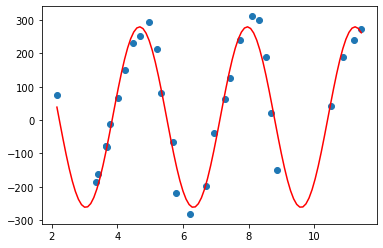

In [5]:
### ANSWER ###
import matplotlib.pyplot as plt

y_best_fit = sin_func(x_new,*popt)
plt.scatter(df["Time (Days)"],df["Velocity (m/s)"])
plt.plot(x_new,y_best_fit,c='r')

#### &#9989;&nbsp; **Part 6 (20 points):**
Before we can conclude if there's a planet present, we need to ensure that our model is a good fit. To do this, we should calculate the Mean Squared Error. Calculate the MSE for our model fit. As a reminder, the expression for MSE is:

$$ MSE = \frac{1}{N}\sum_{i=1}^{N} (y_{fit} - y_{data})^2$$

In [ ]:
#Write code for calculating the MSE here

In [12]:
### ANSWER ###
def MSE(y,y_fit):
    return (1/y.shape[0])*np.sum((y-y_fit)**2.0)

x = df["Time (Days)"]
y = df["Velocity"]
print(f"The MSE value for our best fit line is {MSE(y,sin_func(x, *popt))}")

The MSE value for our best fit line is 1830.8010487016184


#### &#9989;&nbsp; **Part 7 (5 points):**
You know from previous experiments that an MSE $<$ 2000 is considered a pretty good fit for this kind of data. Would this be considered a good fit?

*Write your response here*

### ANSWER ###

The MSE is 1830, which is less than 2000. So it seems like a good fit!

#### &#9989;&nbsp; **Part 8 (5 points):**
Finally, print out your best fit parameters you found in part 3. What did you find for the best fit amplitude $A$? If you assume that a system with an (absolute) amplitude greater than 100 m/s has a planet, would you conclude that there is a planet in this dataset?

In [ ]:
#Write code for printing out best fit parameters here

In [6]:
### ANSWER ###
print(popt)

[270.86084345   3.28125698  42.87722438   9.03608639]


*Write your response here*

### ANSWER ###

The (absolute) amplitude is ~270 m/s, which is greater than 100 m/s. So yes! You can conclude there is a planet.

---

### Congratulations, you're done!

Submit this quiz by uploading it to the course Desire2Learn web page.  Go to the "Quizzes" section, find the submission folder link for Quiz #4, and upload it there.

&#169; Copyright 2021,  Michigan State University Board of Trustees